In [2]:
import pandas as pd 

df = pd.read_csv('data/Kaggle-UrbanSound8K/UrbanSound8K.csv')

In [3]:
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [4]:
random_samples = df.groupby('class').sample(n=1)
random_samples

,slice_file_name,fsID,start,end,salience,fold,classID,class
1399,134717-0-0-26.wav,134717,13.000000,17.000000,1,1,0,air_conditioner
5752,24076-1-1-0.wav,24076,38.856344,42.009706,1,10,1,car_horn
8599,97317-2-0-28.wav,97317,14.000000,18.000000,1,1,2,children_playing
6974,59513-3-0-1.wav,59513,0.656569,4.656569,1,10,3,dog_bark
7929,76086-4-0-50.wav,76086,25.000000,29.000000,1,2,4,drilling
5379,203962-5-0-0.wav,203962,0.000000,4.000000,1,5,5,engine_idling
2979,162432-6-13-0.wav,162432,26.877976,27.712896,1,5,6,gun_shot
6033,30206-7-0-29.wav,30206,14.500000,18.500000,1,6,7,jackhammer
2492,157867-8-0-20.wav,157867,10.000000,14.000000,1,1,8,siren
4937,194733-9-0-12.wav,194733,6.000000,10.000000,1,8,9,street_music


In [5]:
path_dog = 'data/Kaggle-UrbanSound8K/fold3/156418-3-0-1.wav'
path_dog2 = 'data/Kaggle-UrbanSound8K/fold4/102102-3-0-0.wav'
path_drilling = 'data/Kaggle-UrbanSound8K/fold1/147764-4-6-0.wav'

In [ ]:
import librosa
import numpy as np
import tensorflow as tf

SR = 16000
TOP_DB = 30
SR = 16000
NUM_MEL_BINS = 128
NUM_SPECTROGRAM_BINS = 257

# On crée la matrice une fois pour toutes
MEL_WEIGHT_MATRIX = tf.signal.linear_to_mel_weight_matrix(
    NUM_MEL_BINS, 
    NUM_SPECTROGRAM_BINS, 
    SR, 
    80.0, 
    7600.0
)

def load_audio_librosa(file_path):
    # Librosa décode presque TOUT, même les formats WAV non-standards
    audio, _ = librosa.load(file_path.numpy().decode('utf-8'), sr=SR, mono=True)
    
    # On limite/pad à 1 seconde exactement (16000 samples)
    audio = audio[:SR]
    if len(audio) < SR:
        audio = np.pad(audio, (0, SR - len(audio)))
    return audio.astype(np.float32)

def preprocess_mel(file_path, label):
    # Appel de la fonction Python via TensorFlow
    audio = tf.py_function(load_audio_librosa, [file_path], tf.float32)
    
    # 3. Calcul du Mel-Spectrogramme
    # On calcule directement le spectrogramme ici
    stft = tf.signal.stft(audio, frame_length=512, frame_step=256, fft_length=512)
    spectrogram = tf.abs(stft)
    
    # 3. Conversion Mel-Scale (en TensorFlow !)
    num_mel_bins = 128
    # On sait que pour fft_length=512, on a 257 bins
    num_spectrogram_bins = 257
    
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins, 
        num_spectrogram_bins, 
        SR, 
        80.0,  # Lower hertz
        7600.0 # Upper hertz
    )
    
    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    mel_spectrogram.set_shape(spectrogram.shape[:-1].concatenate(
      linear_to_mel_weight_matrix.shape[-1:]))

    # 4. Log-Scale (Décibels)
    log_mel_spec = tf.math.log(mel_spectrogram + 1e-6)

    # 5. Normalisation et Resize
    spec = tf.expand_dims(log_mel_spec, axis=-1)
    spec = tf.ensure_shape(spec, [None, num_mel_bins, 1])
    
    # 4. Resize & Log
    spec = tf.image.resize(spec, [128, 128])
    mean = tf.reduce_mean(spec)
    std = tf.math.reduce_std(spec)
    spec = (spec - mean) / (std + 1e-6)

    return spec, label

def preprocess_single_MFCC(file_path):
    global MEL_WEIGHT_MATRIX, SR
    # Librosa décode presque TOUT, même les formats WAV non-standards
    audio, _ = librosa.load(file_path.numpy().decode('utf-8'), sr=SR, mono=True)
    
    # 1. Split audio: top_db is the threshold (lower = stricter)
    intervals = librosa.effects.split(audio, top_db=TOP_DB)
    
    # 2. Concatenate only the non-silent chunks
    if len(intervals) > 0 : 
        audio_active = np.concatenate([audio[start:end] for start, end in intervals])
    else : 
        audio_active = audio[:SR]
    # On limite/pad à 1 seconde exactement (16000 samples)
    
    if len(audio_active) >= SR:
        audio_active = audio_active[:SR]
    else:
        # FIX IS HERE: use len(audio_active)
        padding_needed = SR - len(audio_active)
        audio_active = np.pad(audio_active, (0, padding_needed))

    with tf.device('/CPU:0'):
        audio_tf = tf.convert_to_tensor(audio_active, dtype=tf.float32)
        audio_tf = tf.reshape(audio_tf, [SR])
        stft = tf.signal.stft(audio_tf, frame_length=512, frame_step=256, fft_length=512)
        spectrogram = tf.abs(stft)
        
        mel_spectrogram = tf.tensordot(spectrogram, MEL_WEIGHT_MATRIX, 1)
        log_mel = tf.math.log(mel_spectrogram + 1e-6)

        # 2. MFCC (40 premiers coefficients)
        # Shape: [Time_frames, 40]
        mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel)[..., :40]

        # 3. Calcul des Deltas (Différences temporelles)
        # On calcule la différence entre la frame t et t-1
        delta = mfccs[1:, :] - mfccs[:-1, :]
        delta2 = delta[1:, :] - delta[:-1, :]

        # 4. Agrégation Statistique (Mean & Std)
        # On réduit sur l'axe du temps (axis=0)
        def get_stats(tensor):
            m = tf.reduce_mean(tensor, axis=0)
            s = tf.math.reduce_std(tensor, axis=0)
            return m, s

        m_mfcc, s_mfcc = get_stats(mfccs)
        m_delta, s_delta = get_stats(delta)
        m_delta2, s_delta2 = get_stats(delta2)

        # 5. Concatenation finale : [40]*6 = 240
        features = tf.concat([m_mfcc, s_mfcc, m_delta, s_delta, m_delta2, s_delta2], axis=0)
    
    return features # Shape [240]
    
def preprocess_audio_MFCC(file_path, label):
    # Appel de la fonction Python via TensorFlow
    mfcc_vector = tf.py_function(preprocess_single_MFCC, [file_path], tf.float32)
    mfcc_vector.set_shape([240])
    
    return mfcc_vector, label

# def create_dataset_mel(files, lbls):
#     ds = tf.data.Dataset.from_tensor_slices((files, lbls))
#     # Ne pas oublier num_parallel_calls pour utiliser ton CPU pendant que le GPU travaille
#     ds = ds.map(preprocess_mel, num_parallel_calls=tf.data.AUTOTUNE)
#     # Batch de 32 recommandé pour ta 4060 avec 1024 filtres
#     return ds.batch(32).prefetch(tf.data.AUTOTUNE)

# def create_dataset_MFCC(files, lbls):
#     ds = tf.data.Dataset.from_tensor_slices((files, lbls))
#     ds = ds.map(preprocess_audio_MFCC, num_parallel_calls=tf.data.AUTOTUNE)
#     return ds.batch(32).prefetch(tf.data.AUTOTUNE)

def create_multi_input_dataset(files, lbls, batch_size=32, training=True):
    # 1. Création du dataset de base
    ds = tf.data.Dataset.from_tensor_slices((files, lbls))
    
    # 2. Mélange des données (uniquement pour l'entraînement)
    if training:
        ds = ds.shuffle(len(files))

    # 3. La fonction de "fusion" interne
    def merge_features(file_path, label):
        # On appelle tes deux fonctions existantes
        mel_image, _ = preprocess_mel(file_path, label)
        mfcc_vector, _ = preprocess_audio_MFCC(file_path, label)
        
        # On retourne le dictionnaire d'entrées + le label
        # IMPORTANT : Les clés doivent être les "name" de tes Input layers
        return {"mel_input": mel_image, "mfcc_input": mfcc_vector}, label

    # 4. Application du mapping
    ds = ds.map(merge_features, num_parallel_calls=tf.data.AUTOTUNE)
    
    # 5. Batching et Prefetching
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_multi_input_dataset(file_paths, labels, training=True)
val_ds = create_multi_input_dataset(val_files, val_labels, training=False)
test_ds = create_multi_input_dataset(test_files, test_labels, training=False)


In [7]:
import os
base_path = 'data/Kaggle-UrbanSound8K'
df = pd.read_csv(os.path.join(base_path, 'UrbanSound8K.csv'))
df_1= df[df['fold'].isin([1, 2, 3, 4, 5, 6, 7, 8])]

def build_path(row):
    return os.path.join(base_path, f"fold{row['fold']}", row['slice_file_name'])
file_paths = df_1.apply(build_path, axis=1).values
labels = df_1['classID'].values

val_files = df[df['fold'] == 9].apply(build_path, axis=1).values
val_labels = df[df['fold'] == 9]['classID'].values

test_files = df[df['fold'] == 10].apply(build_path, axis=1).values
test_labels = df[df['fold'] == 10]['classID'].values


In [38]:
from keras import layers, models
from keras.optimizers import Adam
from keras import Sequential
from keras import regularizers

def build_multi_branch_model(num_classes=10):
    # --- BRANCHE A : Mel-Spectrogramme (Vision) ---
    input_mel = layers.Input(shape=(128, 128, 1), name="mel_input")
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_mel)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    branch_a_out = layers.GlobalAveragePooling2D()(x)

    # --- BRANCHE B : MFCC + Deltas (Statistiques) ---
    input_vector = layers.Input(shape=(240,), name="mfcc_input")
    reg = regularizers.l2(0.01)
    y = layers.Dense(512, activation='relu', kernel_regularizer=reg)(input_vector)
    y = layers.BatchNormalization()(y)
    y = layers.Dropout(0.4)(y)
    
    y = layers.Dense(256, activation='relu')(y)
    y = layers.BatchNormalization()(y)
    y = layers.Dropout(0.4)(y)
    
    y = layers.Dense(128, activation='relu')(y)
    y = layers.BatchNormalization()(y)
    branch_b_out = y

    # --- FUSION ET DÉCISION ---
    combined = layers.Concatenate()([branch_a_out, branch_b_out])
    
    z = layers.Dense(256, activation='relu')(combined)
    z = layers.Dropout(0.5)(z)
    z = layers.Dense(128, activation='relu')(z)
    output = layers.Dense(num_classes, activation='softmax', name="output")(z)

    # CORRECTION : Utilisation de input_vector
    model = models.Model(inputs=[input_mel, input_vector], outputs=output)
    return model

model = build_multi_branch_model(num_classes=10)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=3, 
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=2
    )
]

optimizer = Adam(learning_rate=2*10**-4)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, callbacks= callbacks, epochs=50, verbose=1)

Epoch 1/50


2026-02-20 15:49:16.941079: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 15:49:17.677160: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3171', 20 bytes spill stores, 20 bytes spill loads

2026-02-20 15:49:18.016031: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3171', 272 bytes spill stores, 272 bytes spill loads



222/222 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.4022 - loss: 4.0138 - val_accuracy: 0.1985 - val_loss: 3.8121 - learning_rate: 2.0000e-04
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.5513 - loss: 2.5436 - val_accuracy: 0.5282 - val_loss: 2.2703 - learning_rate: 2.0000e-04
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.6322 - loss: 1.9361 - val_accuracy: 0.7414 - val_loss: 1.6096 - learning_rate: 2.0000e-04
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.6872 - loss: 1.5920 - val_accuracy: 0.6961 - val_loss: 1.5065 - learning_rate: 2.0000e-04
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.7238 - loss: 1.3692 - val_accuracy: 0.7328 - val_loss: 1.2740 - learning_rate: 2.0000e-04
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.7429 - loss: 1.1869 - val_accuracy: 0.7279 - val_loss: 1.1843 - learning_rate: 2.0000e-04
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.76

In [39]:
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 947ms/step


--- RAPPORT DE CLASSIFICATION (MFCC) ---
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       100
           1       0.83      0.88      0.85        33
           2       0.62      0.81      0.70       100
           3       0.73      0.59      0.65       100
           4       0.85      0.82      0.83       100
           5       0.84      0.74      0.79        93
           6       1.00      0.94      0.97        32
           7       0.92      0.86      0.89        96
           8       0.84      0.51      0.63        83
           9       0.74      0.83      0.78       100

    accuracy                           0.78       837
   macro avg       0.81      0.79      0.79       837
weighted avg       0.79      0.78      0.77       837



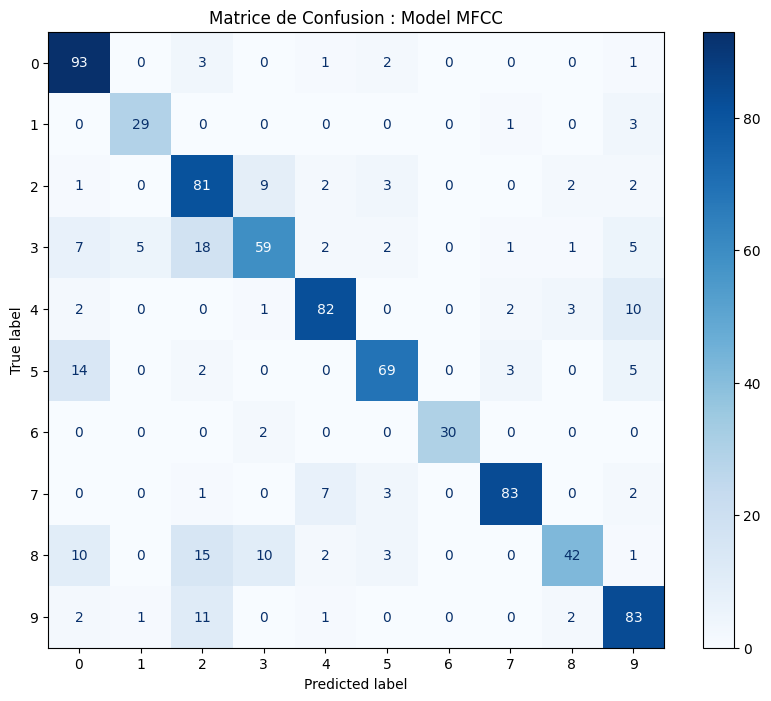

In [40]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- RAPPORT DE CLASSIFICATION (MFCC) ---")
print(classification_report(test_labels, y_pred_classes))

# Affichage de la Matrice de Confusion
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(test_labels, y_pred_classes, ax=ax, cmap='Blues')
plt.title("Matrice de Confusion : Model MFCC")
plt.show()